<a href="https://colab.research.google.com/github/kwesiewul2005-prog/syntexhub/blob/main/syntecxhub_Flower_Classification%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- First 5 Rows of Dataset ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

--- Summary Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    flo

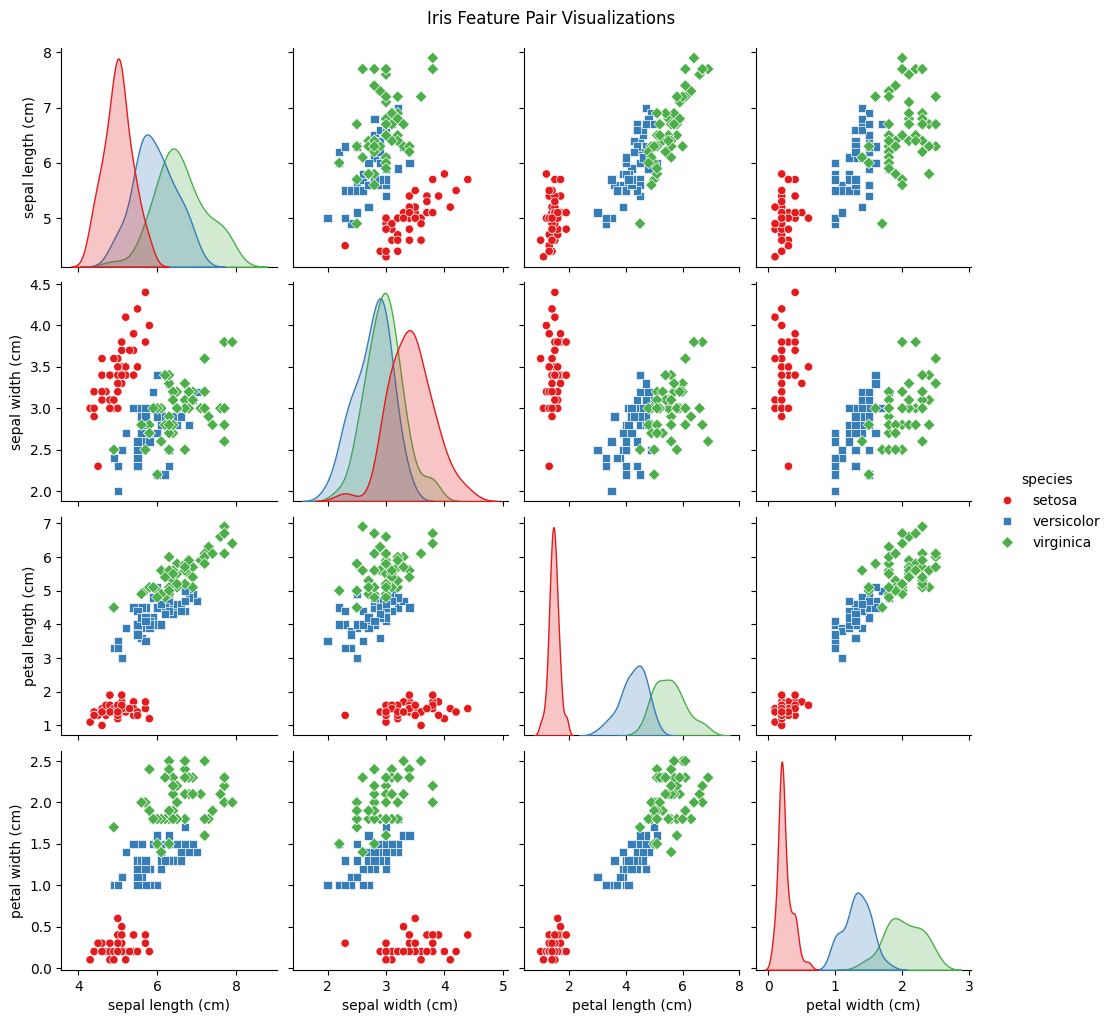


Logistic Regression Accuracy: 96.67%
Decision Tree Accuracy:       93.33%


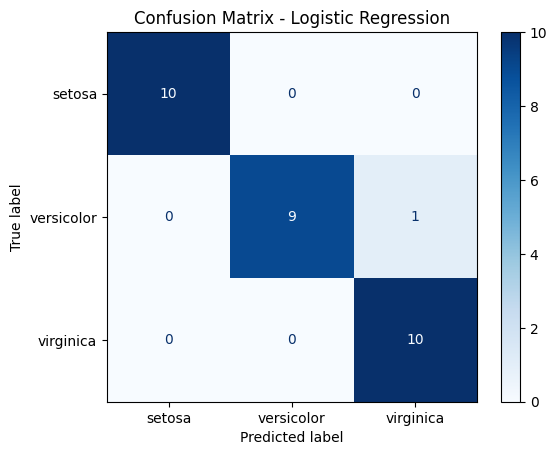


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Total Misclassifications: 1
Actual: versicolor | Predicted: virginica

--- Iris Flower Species Predictor (CLI) ---
Enter Sepal Length (cm): 5.1
Enter Sepal Width (cm): 3.5
Enter Petal Length (cm): 1.4
Enter Petal Width (cm): 0.2

Result: The predicted flower species is -> **SETOSA**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# ==========================================
# 1. Load the Iris Dataset & Initial Setup
# ==========================================
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("--- First 5 Rows of Dataset ---")
print(df.head())
print("\n--- Summary Information ---")
print(df.info())

# ==========================================
# 2. Exploratory Data Analysis (EDA)
# ==========================================
# Pairplot to visualize feature pairs across species
sns.pairplot(df, hue='species', markers=["o", "s", "D"], palette='Set1')
plt.suptitle("Iris Feature Pair Visualizations", y=1.02)
plt.savefig("iris_pairplot.png")
plt.show()

# ==========================================
# 3. Model Training & Comparison
# ==========================================
X = iris.data
y = iris.target

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize Classifiers
log_reg = LogisticRegression(max_iter=200, random_state=42)
dt_classifier = DecisionTreeClassifier(random_state=42)

# Fit Models
log_reg.fit(X_train, y_train)
dt_classifier.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_dt = dt_classifier.predict(X_test)

# Accuracy Evaluation
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("\n==========================================")
print(f"Logistic Regression Accuracy: {acc_lr * 100:.2f}%")
print(f"Decision Tree Accuracy:       {acc_dt * 100:.2f}%")
print("==========================================")

# ==========================================
# 4. Confusion Matrix & Misclassification
# ==========================================
# Plot Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("confusion_matrix.png")
plt.show()

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))

# Identify misclassifications (if any)
misclassified_idx = np.where(y_test != y_pred_lr)[0]
if len(misclassified_idx) == 0:
    print("No misclassifications occurred on the test dataset.")
else:
    print(f"\nTotal Misclassifications: {len(misclassified_idx)}")
    for idx in misclassified_idx:
        print(f"Actual: {iris.target_names[y_test[idx]]} | Predicted: {iris.target_names[y_pred_lr[idx]]}")

# ==========================================
# 5. Prediction Script / Interactive CLI
# ==========================================
def predict_flower_species(model):
    print("\n--- Iris Flower Species Predictor (CLI) ---")
    try:
        sepal_length = float(input("Enter Sepal Length (cm): "))
        sepal_width  = float(input("Enter Sepal Width (cm): "))
        petal_length = float(input("Enter Petal Length (cm): "))
        petal_width  = float(input("Enter Petal Width (cm): "))

        sample = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
        prediction = model.predict(sample)[0]
        predicted_class = iris.target_names[prediction]

        print(f"\nResult: The predicted flower species is -> **{predicted_class.upper()}**")
    except ValueError:
        print("Invalid input. Please enter numeric values.")

# Run CLI Prediction
predict_flower_species(log_reg)